In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error
import random
import warnings

In [18]:
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 12

## 1. Dataset Loading and Visualization

In [19]:
df = pd.read_excel('dataset.xlsx')

print("Dataset Preview:")
display(df.head())

print("\nDataset Information:")
display(df.info())

print("\nMissing Values Count:")
display(df.isnull().sum())

Dataset Preview:


,Tanggal,Tn,Tx,Tavg,RH_avg,RR,ss,ff_x,ddd_x,ff_avg,ddd_car
0,01-01-2020,24.2,31.4,27.0,88,9.6,3.6,6,280,4,W
1,02-01-2020,24.0,31.0,27.4,87,16.7,3.4,6,280,3,W
2,03-01-2020,24.8,32.2,28.4,84,2.0,2.5,7,270,3,W
3,04-01-2020,22.0,31.4,27.1,90,36.6,4.6,8,270,2,C
4,05-01-2020,25.4,30.4,26.8,92,3.7,0.8,6,270,2,C



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1355 entries, 0 to 1354
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Tanggal  1355 non-null   object 
 1   Tn       1355 non-null   float64
 2   Tx       1355 non-null   float64
 3   Tavg     1355 non-null   float64
 4   RH_avg   1355 non-null   int64  
 5   RR       1331 non-null   float64
 6   ss       1355 non-null   float64
 7   ff_x     1355 non-null   int64  
 8   ddd_x    1355 non-null   int64  
 9   ff_avg   1355 non-null   int64  
 10  ddd_car  1355 non-null   object 
dtypes: float64(5), int64(4), object(2)
memory usage: 116.6+ KB


None


Missing Values Count:


Tanggal     0
Tn          0
Tx          0
Tavg        0
RH_avg      0
RR         24
ss          0
ff_x        0
ddd_x       0
ff_avg      0
ddd_car     0
dtype: int64

Now, let's convert the 'Tanggal' column to the proper datetime format and set it as the index.

In [20]:
df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='%d-%m-%Y', errors='coerce')
print("Datetime Conversion Check:")
display(df['Tanggal'].head())

# Check if any dates couldn't be parsed (will show as NaT)
print(f"Number of unparsed dates: {df['Tanggal'].isna().sum()}")

# Set the 'Tanggal' column as the index
df.set_index('Tanggal', inplace=True)

# Sort the index to ensure chronological order
df.sort_index(inplace=True)

Datetime Conversion Check:


0   2020-01-01
1   2020-01-02
2   2020-01-03
3   2020-01-04
4   2020-01-05
Name: Tanggal, dtype: datetime64[ns]

Number of unparsed dates: 0


Our dataset contains the following climate variables for Semarang:
* **Tn:** Minimum Temperature (°C)
* **Tx:** Maximum Temperature (°C)
* **Tavg:** Average Temperature (°C)
* **RH_avg:** Average Humidity (%)
* **RR:** Rainfall (mm)
* **ss:** Duration of Sunshine (hours)
* **ff_x:** Maximum Wind Speed (m/s)
* **ddd_x:** Wind Direction at Maximum Speed (°)
* **ff_avg:** Average Wind Speed (m/s)
* **ddd_car:** Most Common Wind Direction (°)

For this analysis, we'll focus on the **Average Temperature (Tavg)** as our main time series variable because:
1. Temperature data typically shows clear seasonal patterns
2. It's usually more complete with fewer missing values
3. Temperature is continuous and well-suited for various interpolation methods
4. The results will be easier to interpret

Let's visualize our time series data:

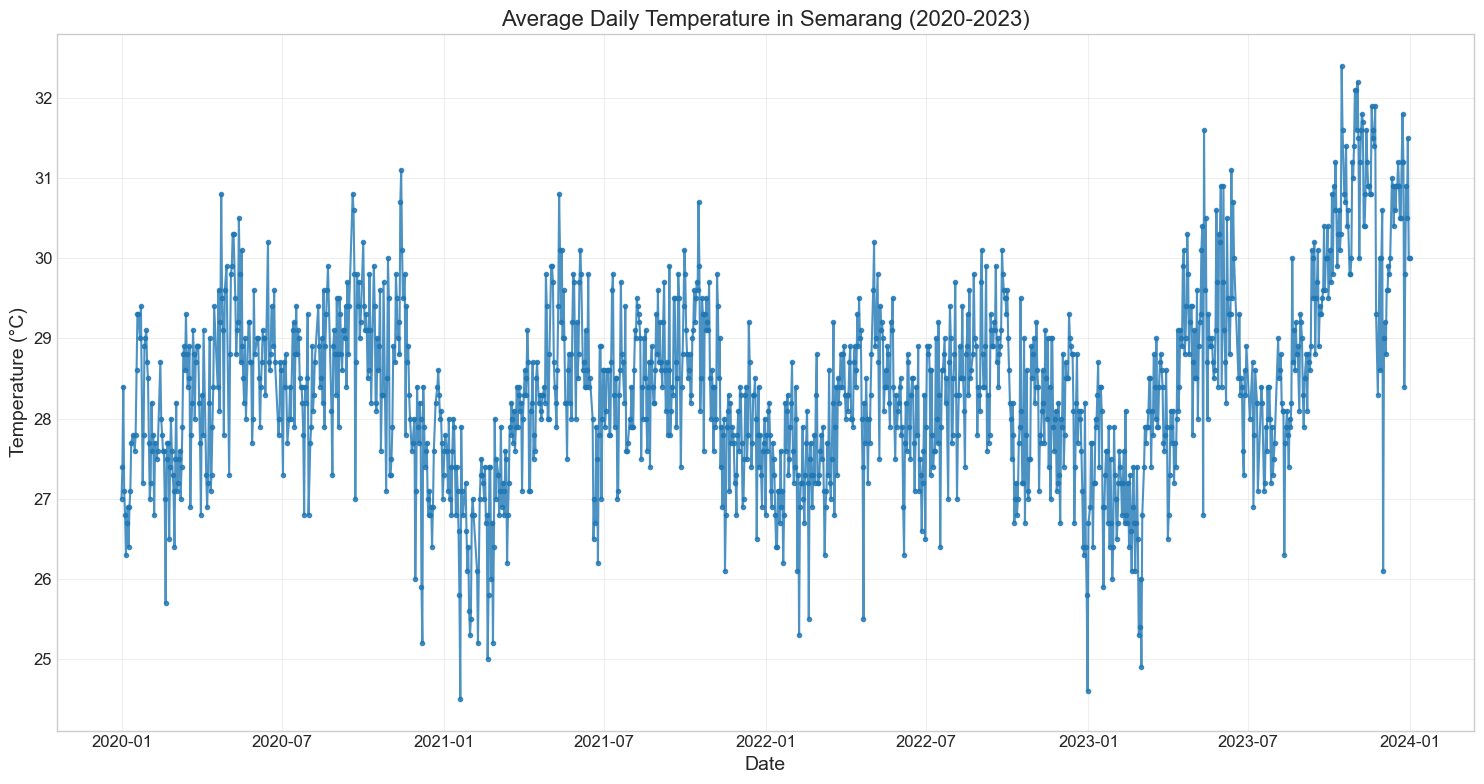

In [21]:
plt.figure(figsize=(15, 8))
plt.plot(df.index, df['Tavg'], marker='.', linestyle='-', alpha=0.8, color='#1f77b4')
plt.title('Average Daily Temperature in Semarang (2020-2023)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Temperature (°C)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Statistical Analysis

In [22]:
stats = df['Tavg'].describe()
print("Statistical Analysis of Average Temperature:")
display(stats)

report = {
    'Mean': df['Tavg'].mean(),
    'Median': df['Tavg'].median(),
    'Variance': df['Tavg'].var(),
    'Standard Deviation': df['Tavg'].std(),
    'Min': df['Tavg'].min(),
    'Max': df['Tavg'].max(),
    'Range': df['Tavg'].max() - df['Tavg'].min(),
    'Skewness': df['Tavg'].skew(),
    'Kurtosis': df['Tavg'].kurtosis(),
    'First Quartile (25%)': df['Tavg'].quantile(0.25),
    'Third Quartile (75%)': df['Tavg'].quantile(0.75),
    'Interquartile Range (IQR)': df['Tavg'].quantile(0.75) - df['Tavg'].quantile(0.25)
}

for stat, value in report.items():
    print(f"{stat}: {value:.4f}")

Statistical Analysis of Average Temperature:


count    1355.000000
mean       28.359926
std         1.161728
min        24.500000
25%        27.600000
50%        28.300000
75%        29.000000
max        32.400000
Name: Tavg, dtype: float64

Mean: 28.3599
Median: 28.3000
Variance: 1.3496
Standard Deviation: 1.1617
Min: 24.5000
Max: 32.4000
Range: 7.9000
Skewness: 0.2913
Kurtosis: 0.6149
First Quartile (25%): 27.6000
Third Quartile (75%): 29.0000
Interquartile Range (IQR): 1.4000


Let's also look at the monthly and yearly patterns in our temperature data:

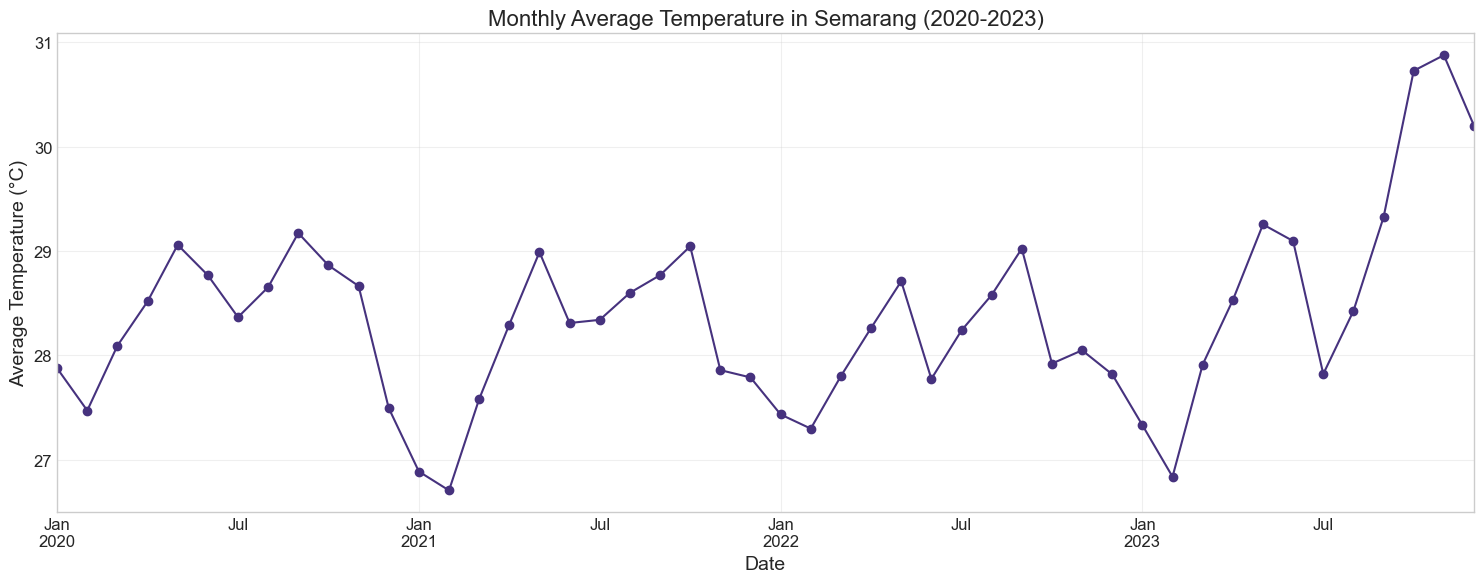


Yearly Average Temperature:


Tanggal
2020-12-31    28.395541
2021-12-31    28.126225
2022-12-31    28.074230
2023-12-31    28.870030
Freq: YE-DEC, Name: Tavg, dtype: float64

In [23]:
monthly_avg = df['Tavg'].resample('M').mean()

plt.figure(figsize=(15, 6))
monthly_avg.plot(marker='o', linestyle='-')
plt.title('Monthly Average Temperature in Semarang (2020-2023)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Average Temperature (°C)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

yearly_avg = df['Tavg'].resample('Y').mean()
print("\nYearly Average Temperature:")
display(yearly_avg)

## 3. Introduce Missing Values

In [24]:
df_missing = df.copy()

# Randomly remove a subset of data points (10% of the data)
np.random.seed(42) 
n_missing = int(len(df_missing) * 0.1)
missing_indices = random.sample(range(len(df_missing)), n_missing)
df_missing.loc[df_missing.index[missing_indices], 'Tavg'] = np.nan

# Count the missing values
print("Missing Values after Artificial Removal:")
print(f"Number of missing values: {df_missing['Tavg'].isnull().sum()}")
print(f"Percentage of missing values: {df_missing['Tavg'].isnull().sum() / len(df_missing['Tavg']) * 100:.2f}%")

Missing Values after Artificial Removal:
Number of missing values: 135
Percentage of missing values: 9.96%


Let's visualize the impact of these missing values on our time series:

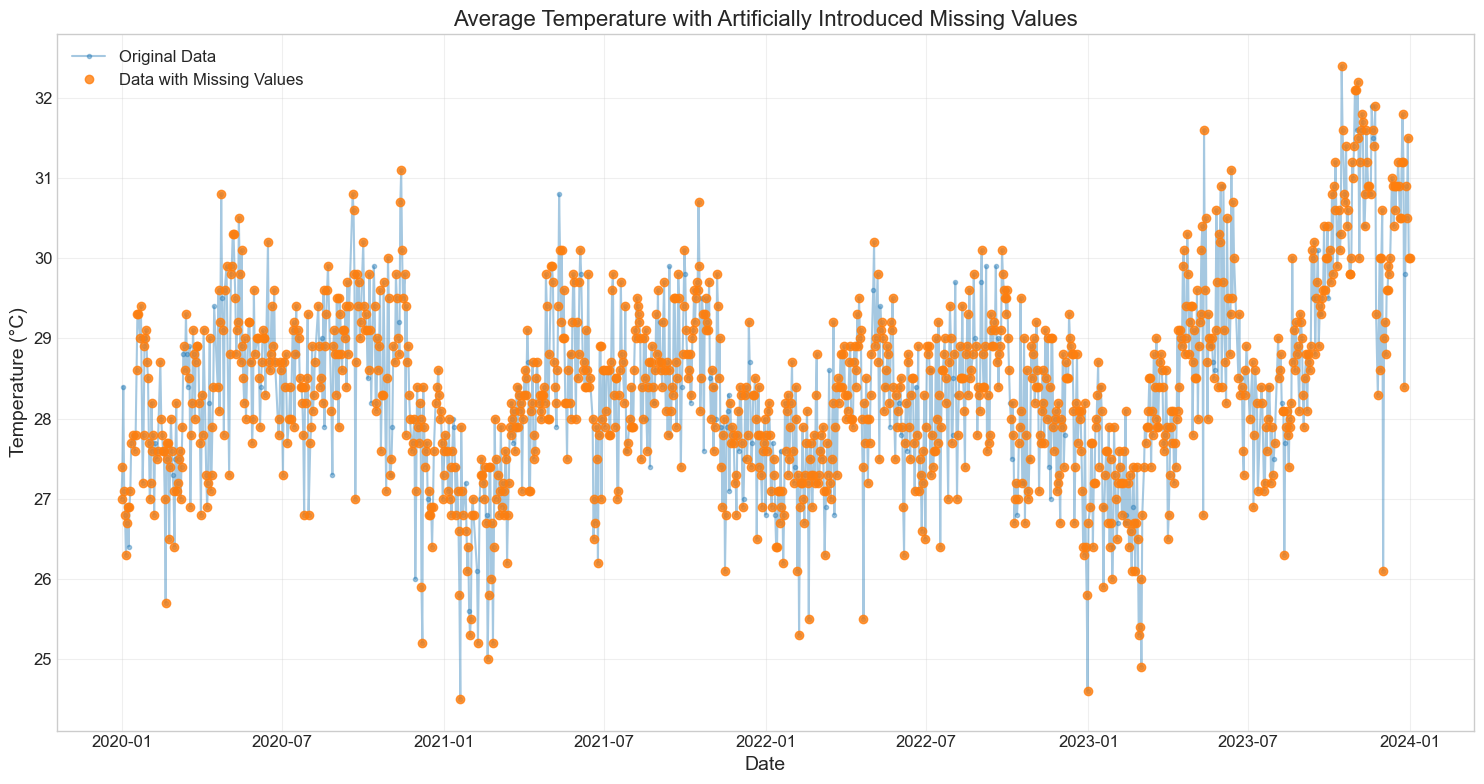

In [25]:
plt.figure(figsize=(15, 8))
plt.plot(df.index, df['Tavg'], marker='.', linestyle='-', alpha=0.4, color='#1f77b4', label='Original Data')
plt.plot(df_missing.index, df_missing['Tavg'], marker='o', linestyle=' ', alpha=0.8, color='#ff7f0e', label='Data with Missing Values')
plt.title('Average Temperature with Artificially Introduced Missing Values', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Temperature (°C)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**We'll zoom in to focus on a specifit part of the time series for better vizualization**

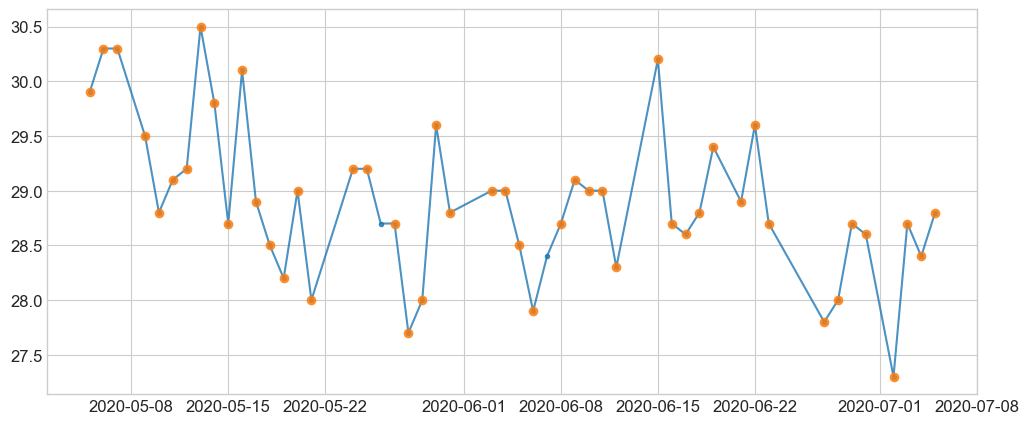

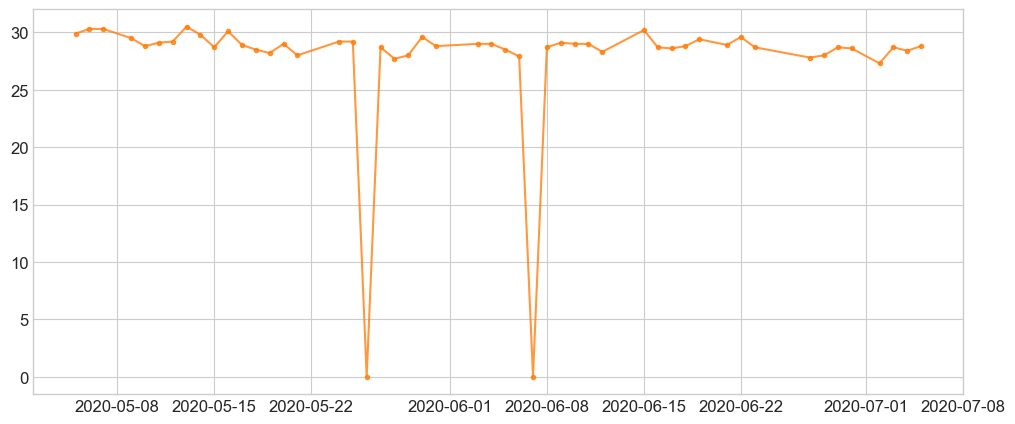

In [26]:
interest_df = df[110:160]
missing_interest_df = df_missing[110:160]
plt.figure(figsize=(12, 5))
plt.plot(interest_df.index, interest_df['Tavg'], marker='.', linestyle='-', alpha=0.8, color='#1f77b4')
plt.plot(missing_interest_df.index, missing_interest_df['Tavg'], marker='o', linestyle='', alpha=0.8, color='#ff7f0e')
plt.show()

missing_interest_copy = missing_interest_df.copy()
missing_interest_copy.fillna(0, inplace=True)
plt.figure(figsize=(12, 5))
plt.plot(missing_interest_copy.index, missing_interest_copy['Tavg'], marker='.', linestyle='-', alpha=0.8, color='#ff7f0e')
plt.show()

Now, we'll implement several strategies to handle these missing values and compare their effectiveness.

In [27]:
df_ffill = missing_interest_df.copy()  # Forward fill
df_bfill = missing_interest_df.copy()  # Backward fill
df_interp_linear = missing_interest_df.copy()  # Linear interpolation
df_interp_ma = missing_interest_df.copy()  # Moving average

df_ffill['Tavg'] = df_ffill['Tavg'].ffill()

df_bfill['Tavg'] = df_bfill['Tavg'].bfill()

df_interp_linear['Tavg'] = df_interp_linear['Tavg'].interpolate(method='linear')

# Moving Average Interpolation (Using a 7-day window)
df_temp = missing_interest_df.copy()
df_temp['Tavg'] = df_temp['Tavg'].interpolate(method='linear')
# Then apply rolling average
window_size = 4
df_interp_ma['Tavg'] = df_temp['Tavg'].rolling(window=window_size, center=True, min_periods=1).mean()


Let's visualize all these imputation strategies to compare their effectiveness:

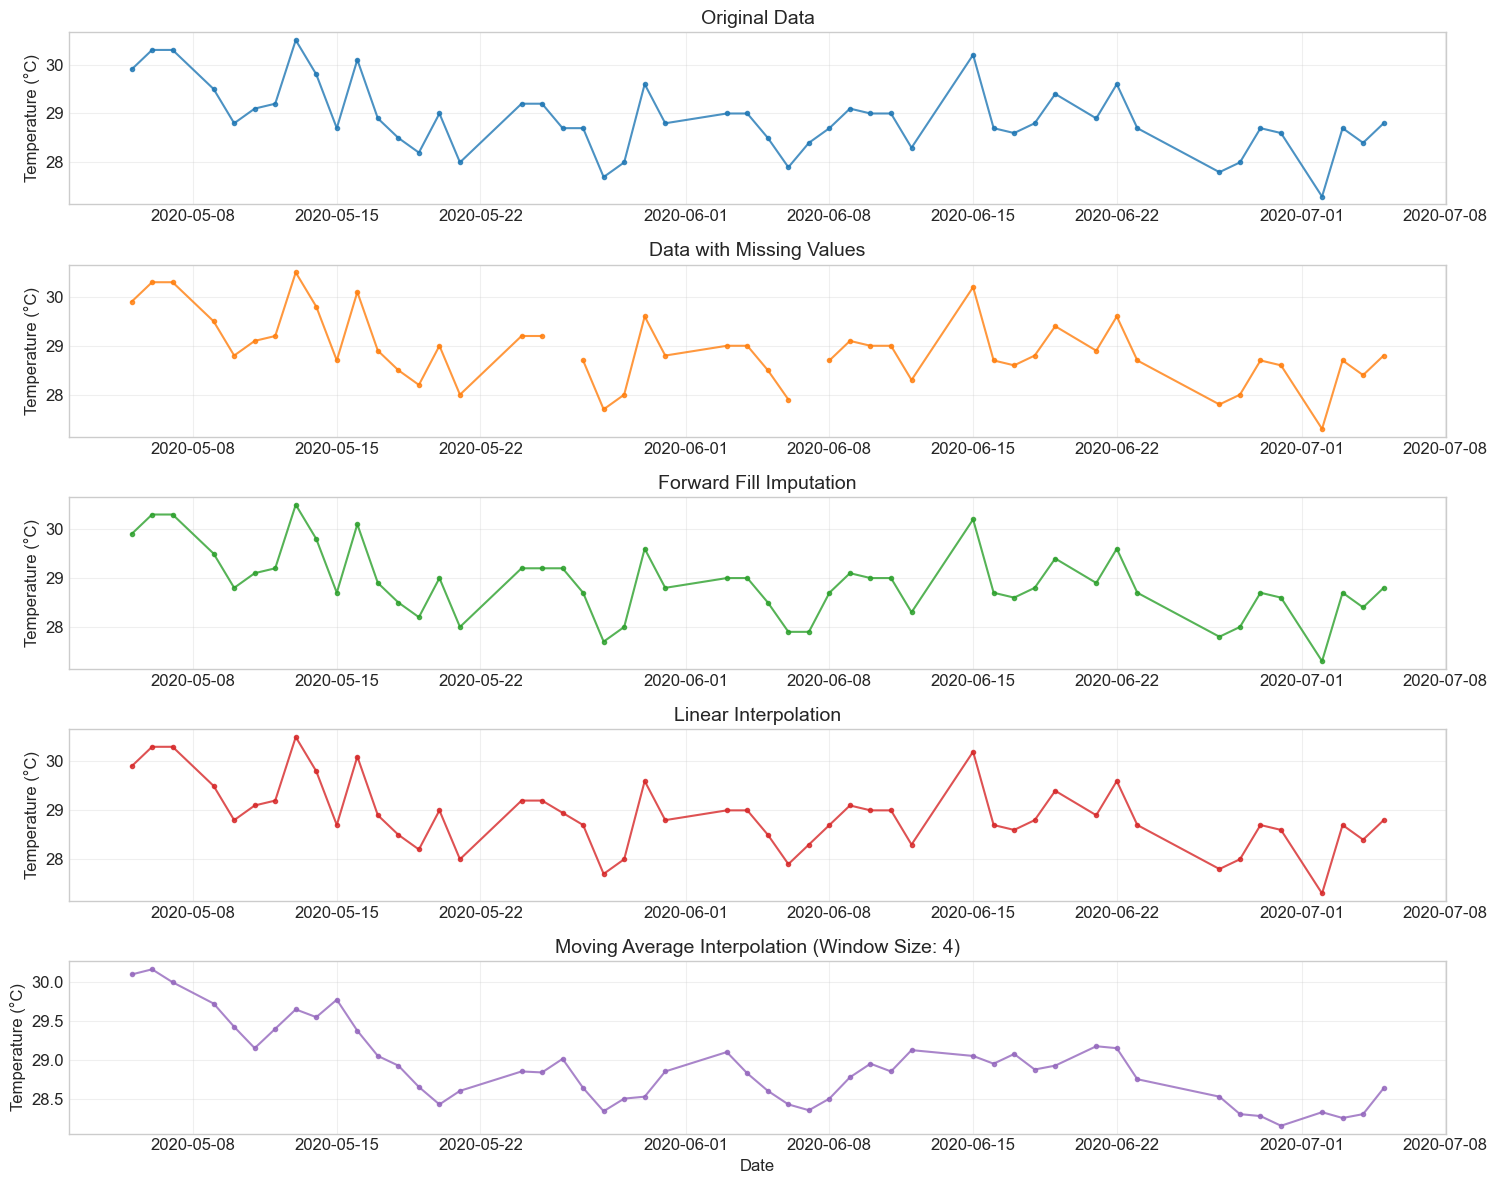

In [28]:
plt.figure(figsize=(15, 12))

# Original data
plt.subplot(5, 1, 1)
plt.plot(interest_df.index, interest_df['Tavg'], marker='.', linestyle='-', alpha=0.8, color='#1f77b4')
plt.title('Original Data', fontsize=14)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(True, alpha=0.3)

# Missing data
plt.subplot(5, 1, 2)
plt.plot(missing_interest_df.index, missing_interest_df['Tavg'], marker='.', linestyle='-', alpha=0.8, color='#ff7f0e')
plt.title('Data with Missing Values', fontsize=14)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(True, alpha=0.3)

# Forward Fill
plt.subplot(5, 1, 3)
plt.plot(df_ffill.index, df_ffill['Tavg'], marker='.', linestyle='-', alpha=0.8, color='#2ca02c')
plt.title('Forward Fill Imputation', fontsize=14)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(True, alpha=0.3)

# Linear Interpolation
plt.subplot(5, 1, 4)
plt.plot(df_interp_linear.index, df_interp_linear['Tavg'], marker='.', linestyle='-', alpha=0.8, color='#d62728')
plt.title('Linear Interpolation', fontsize=14)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(True, alpha=0.3)

# Moving Average
plt.subplot(5, 1, 5)
plt.plot(df_interp_ma.index, df_interp_ma['Tavg'], marker='.', linestyle='-', alpha=0.8, color='#9467bd')
plt.title(f'Moving Average Interpolation (Window Size: {window_size})', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Decomposition

Using period=7 for seasonal decomposition


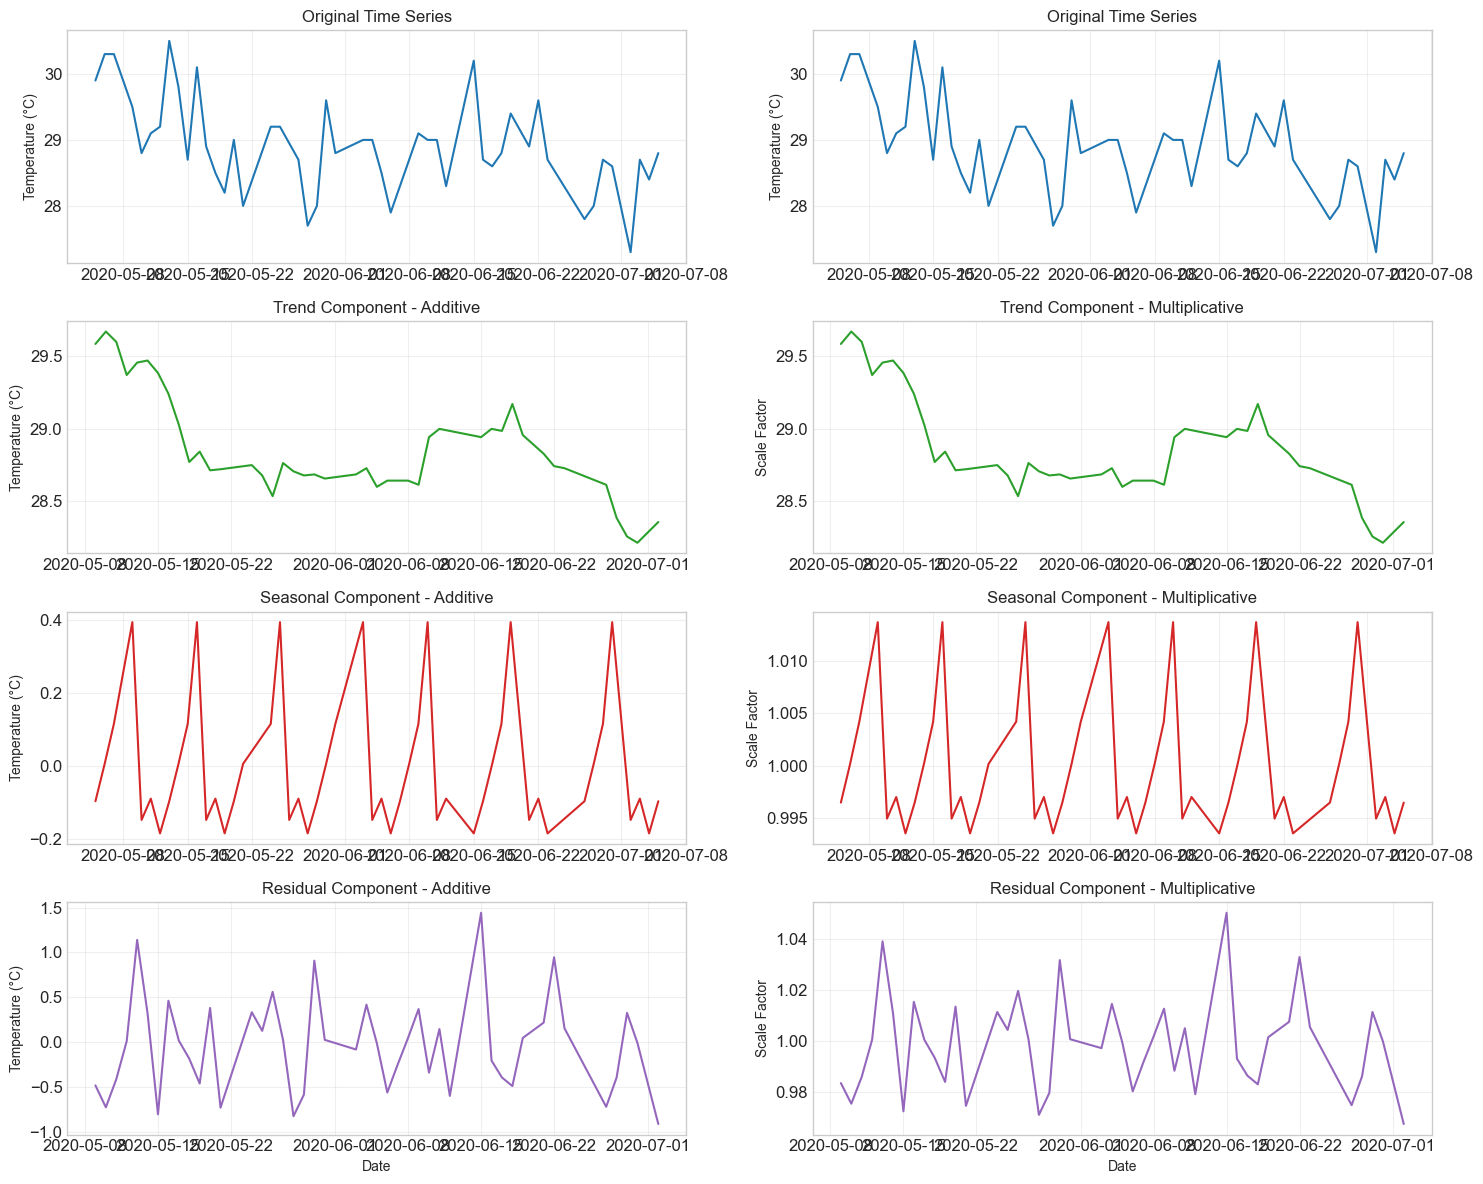


Residual Analysis:
Additive Model: Mean = -0.0384, Std = 0.5411, Abs Mean = 0.4222
Multiplicative Model: Mean = 0.9987, Std = 0.0188, Abs Mean = 0.9987


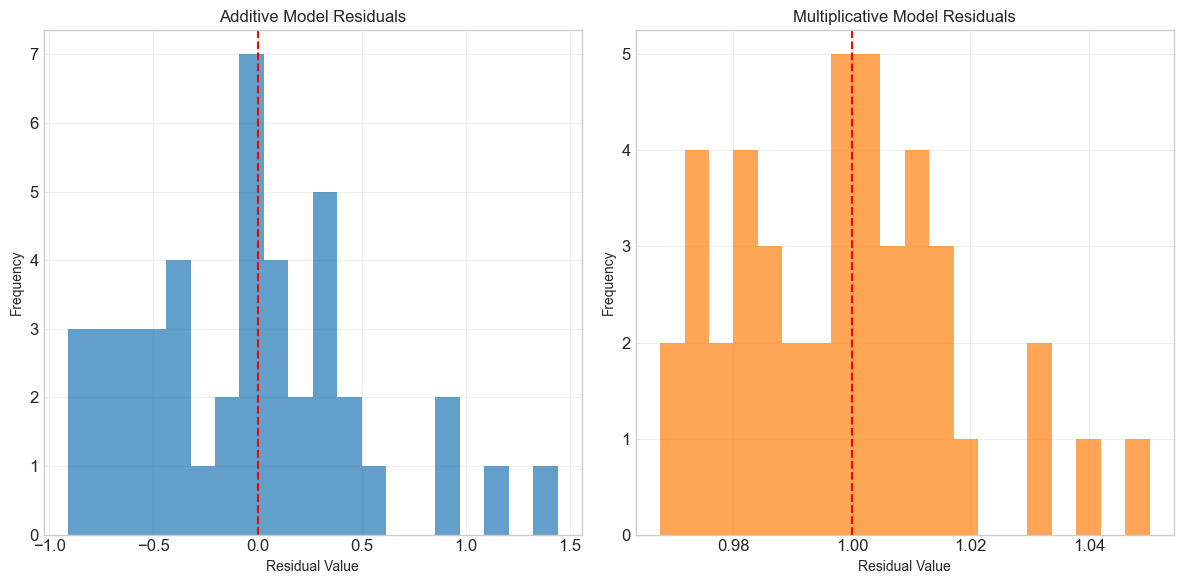

In [29]:
from statsmodels.tsa.seasonal import seasonal_decompose
import numpy as np

decomposition_data = df_interp_linear.copy()

# For daily temperature data, we need to set an appropriate period
# Let's try with a weekly period (7 days)
period = 7  # Assuming weekly patterns in temperature data

# Check if we have enough data for this period
if len(decomposition_data) < 2 * period + 1:
    print(f"Warning: Not enough data points for period={period}. Reducing period.")
    period = max(2, len(decomposition_data) // 3)  # Ensure we have at least period=2

print(f"Using period={period} for seasonal decomposition")

# Additive Decomposition
additive_decomposition = seasonal_decompose(decomposition_data['Tavg'], model='additive', period=period)

# Multiplicative Decomposition
if (decomposition_data['Tavg'] <= 0).any():
    print("Warning: Data contains zeros or negative values. Adding a constant for multiplicative decomposition.")
    # Shift data to ensure all positive values
    min_temp = decomposition_data['Tavg'].min()
    if min_temp <= 0:
        offset = abs(min_temp) + 1  # Add 1 to ensure all positive
        temp_data = decomposition_data['Tavg'] + offset
    else:
        temp_data = decomposition_data['Tavg']
    
    multiplicative_decomposition = seasonal_decompose(temp_data, model='multiplicative', period=period)
else:
    multiplicative_decomposition = seasonal_decompose(decomposition_data['Tavg'], model='multiplicative', period=period)

plt.figure(figsize=(15, 12))

# Additive Decomposition
plt.subplot(4, 2, 1)
plt.plot(decomposition_data.index, decomposition_data['Tavg'], color='#1f77b4')
plt.title('Original Time Series', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=10)
plt.grid(True, alpha=0.3)

plt.subplot(4, 2, 3)
plt.plot(additive_decomposition.trend.index, additive_decomposition.trend, color='#2ca02c')
plt.title('Trend Component - Additive', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=10)
plt.grid(True, alpha=0.3)

plt.subplot(4, 2, 5)
plt.plot(additive_decomposition.seasonal.index, additive_decomposition.seasonal, color='#d62728')
plt.title('Seasonal Component - Additive', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=10)
plt.grid(True, alpha=0.3)

plt.subplot(4, 2, 7)
plt.plot(additive_decomposition.resid.index, additive_decomposition.resid, color='#9467bd')
plt.title('Residual Component - Additive', fontsize=12)
plt.xlabel('Date', fontsize=10)
plt.ylabel('Temperature (°C)', fontsize=10)
plt.grid(True, alpha=0.3)

# Multiplicative Decomposition
plt.subplot(4, 2, 2)
plt.plot(decomposition_data.index, decomposition_data['Tavg'], color='#1f77b4')
plt.title('Original Time Series', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=10)
plt.grid(True, alpha=0.3)

plt.subplot(4, 2, 4)
plt.plot(multiplicative_decomposition.trend.index, multiplicative_decomposition.trend, color='#2ca02c')
plt.title('Trend Component - Multiplicative', fontsize=12)
plt.ylabel('Scale Factor', fontsize=10)
plt.grid(True, alpha=0.3)

plt.subplot(4, 2, 6)
plt.plot(multiplicative_decomposition.seasonal.index, multiplicative_decomposition.seasonal, color='#d62728')
plt.title('Seasonal Component - Multiplicative', fontsize=12)
plt.ylabel('Scale Factor', fontsize=10)
plt.grid(True, alpha=0.3)

plt.subplot(4, 2, 8)
plt.plot(multiplicative_decomposition.resid.index, multiplicative_decomposition.resid, color='#9467bd')
plt.title('Residual Component - Multiplicative', fontsize=12)
plt.xlabel('Date', fontsize=10)
plt.ylabel('Scale Factor', fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

add_resid_mean = additive_decomposition.resid.mean()
add_resid_std = additive_decomposition.resid.std()
add_resid_abs_mean = np.abs(additive_decomposition.resid).mean()

mult_resid_mean = multiplicative_decomposition.resid.mean()
mult_resid_std = multiplicative_decomposition.resid.std()
mult_resid_abs_mean = np.abs(multiplicative_decomposition.resid).mean()

print("\nResidual Analysis:")
print(f"Additive Model: Mean = {add_resid_mean:.4f}, Std = {add_resid_std:.4f}, Abs Mean = {add_resid_abs_mean:.4f}")
print(f"Multiplicative Model: Mean = {mult_resid_mean:.4f}, Std = {mult_resid_std:.4f}, Abs Mean = {mult_resid_abs_mean:.4f}")

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(additive_decomposition.resid.dropna(), bins=20, alpha=0.7, color='#1f77b4')
plt.title('Additive Model Residuals', fontsize=12)
plt.xlabel('Residual Value', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.axvline(x=0, color='red', linestyle='--')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(multiplicative_decomposition.resid.dropna(), bins=20, alpha=0.7, color='#ff7f0e')
plt.title('Multiplicative Model Residuals', fontsize=12)
plt.xlabel('Residual Value', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.axvline(x=1, color='red', linestyle='--')  
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Why additive is more appropriate: Temperature variations typically don't scale proportionally with the baseline temperature. The day-night temperature difference tends to be fairly constant regardless of the absolute temperature.

## Generating Syntethic Data

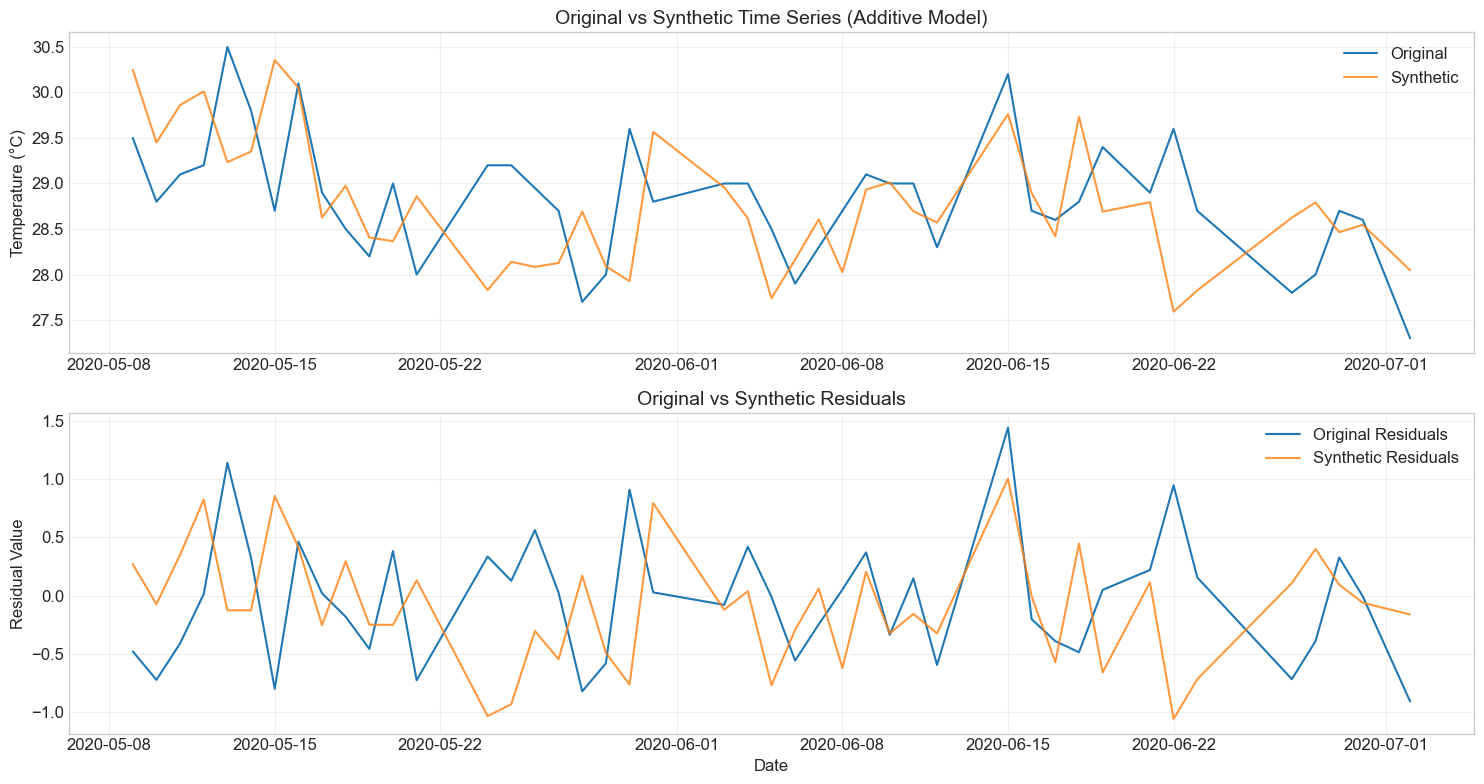

Correlation between original and synthetic time series: 0.3490

Summary Statistics Comparison:
Original Time Series (valid indices only):
Mean: 28.8307
Std: 0.6630
Min: 27.3000
Max: 30.5000

Synthetic Time Series:
Mean: 28.7676
Std: 0.7095
Min: 27.5934
Max: 30.3561


In [30]:
# Get valid indices where none of the components have NaN values
valid_indices = additive_decomposition.trend.dropna().index.intersection(
    additive_decomposition.seasonal.dropna().index
).intersection(
    additive_decomposition.resid.dropna().index
)

# Generate new residual component
np.random.seed(42)  # For reproducibility
new_residuals = np.random.normal(
    loc=0,  # Mean centered at 0
    scale=additive_decomposition.resid.loc[valid_indices].std(),  # Same std as original
    size=len(valid_indices)
)

# Create a DataFrame with the same valid indices
new_residuals_df = pd.DataFrame(
    new_residuals, 
    index=valid_indices,
    columns=['new_resid']
)

# Recompose the signal using the same Trend, Seasonality and the new residual component
# For additive model: Y = Trend + Seasonality + Residual
synthetic_ts_additive = pd.Series(
    additive_decomposition.trend.loc[valid_indices] +
    additive_decomposition.seasonal.loc[valid_indices] +
    new_residuals_df['new_resid'],
    index=valid_indices,
    name='Synthetic_Tavg'
)

plt.figure(figsize=(15, 8))

plt.subplot(2, 1, 1)
plt.plot(decomposition_data.loc[valid_indices, 'Tavg'], label='Original', color='#1f77b4')
plt.plot(synthetic_ts_additive, label='Synthetic', color='#ff7f0e', alpha=0.8)
plt.title('Original vs Synthetic Time Series (Additive Model)', fontsize=14)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(additive_decomposition.resid.loc[valid_indices], label='Original Residuals', color='#1f77b4')
plt.plot(new_residuals_df['new_resid'], label='Synthetic Residuals', color='#ff7f0e', alpha=0.8)
plt.title('Original vs Synthetic Residuals', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Residual Value', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

correlation = np.corrcoef(
    decomposition_data.loc[valid_indices, 'Tavg'].values,
    synthetic_ts_additive.values
)[0, 1]

print(f"Correlation between original and synthetic time series: {correlation:.4f}")

print("\nSummary Statistics Comparison:")
print("Original Time Series (valid indices only):")
print(f"Mean: {decomposition_data.loc[valid_indices, 'Tavg'].mean():.4f}")
print(f"Std: {decomposition_data.loc[valid_indices, 'Tavg'].std():.4f}")
print(f"Min: {decomposition_data.loc[valid_indices, 'Tavg'].min():.4f}")
print(f"Max: {decomposition_data.loc[valid_indices, 'Tavg'].max():.4f}")

print("\nSynthetic Time Series:")
print(f"Mean: {synthetic_ts_additive.mean():.4f}")
print(f"Std: {synthetic_ts_additive.std():.4f}")
print(f"Min: {synthetic_ts_additive.min():.4f}")
print(f"Max: {synthetic_ts_additive.max():.4f}")